In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100, penalty=None, alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0 # b
        self.theta_1 = 0.0 # w
        self.alpha = alpha
        self.penalty = penalty
        self.cost_values = []

    def fit(self, x, y):
        for i in range(self.n_iters):
            y_hat = self.theta_1 * x + self.theta_0
            error = y_hat - y
            d_w = np.mean(error * x)
            d_b = np.mean(error * 1)
            
            if self.penalty == 'l2': # Ridge
                d_w += (self.alpha / len(x)) * self.theta_1
            elif self.penalty == 'l1': # Lasso
                d_w += (self.alpha / len(x)) * np.sign(self.theta_1)
            
            self.theta_1 = self.theta_1 - self.learning_rate * d_w
            self.theta_0 = self.theta_0 - self.learning_rate * d_b
            
            cost = 0.5 * np.mean((y_hat - y)**2)
            if self.penalty == 'l2':
                cost += (self.alpha / (2 * len(x))) * (self.theta_1 ** 2)
            elif self.penalty == 'l1':
                cost += (self.alpha / len(x)) * abs(self.theta_1)
            
            self.cost_values.append(cost)
            
            if (i+1) % 100 == 0 or i == 0:
                print(f"epoch {i+1}: \n cost = {cost} \n w = {self.theta_1} \n b = {self.theta_0}\n")

    def predict(self, x):
        return self.theta_1 * x + self.theta_0
    
    def plot_training(self, x, y):
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.scatter(x, y)
        plt.plot(x, self.theta_1 * x + self.theta_0, 'r')
        plt.title("Linear Regression")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(self.cost_values)
        plt.title("Cost vs Epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Cost")
        plt.grid()
        
        plt.show()

In [3]:
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 4 + 3 * X + np.random.randn(100) * 0.5

In [4]:
model = LinearRegressionGD(learning_rate=0.05, n_iters=1000, penalty='l2', alpha=0.1)
model.fit(X, y)

epoch 1: 
 cost = 24.819339329412788 
 w = 0.37124367767272787 
 b = 0.3410272140092789

epoch 100: 
 cost = 0.12686072281749647 
 w = 3.2096118657399106 
 b = 3.738053103965369

epoch 200: 
 cost = 0.10893457142662887 
 w = 3.0184820511805124 
 b = 3.9547717048583375

epoch 300: 
 cost = 0.1056895386388785 
 w = 2.9371193546910015 
 b = 4.04696949458536

epoch 400: 
 cost = 0.10510239635732552 
 w = 2.9024960133847015 
 b = 4.086203634951061

epoch 500: 
 cost = 0.10499628145220215 
 w = 2.887762286546607 
 b = 4.102899455893387

epoch 600: 
 cost = 0.10497715433077043 
 w = 2.881492449542171 
 b = 4.1100042486667245

epoch 700: 
 cost = 0.10497372849208986 
 w = 2.878824363151391 
 b = 4.113027644792405

epoch 800: 
 cost = 0.10497312421739355 
 w = 2.877688977178259 
 b = 4.114314230400794

epoch 900: 
 cost = 0.10497302164241179 
 w = 2.8772058214182206 
 b = 4.114861728134769

epoch 1000: 
 cost = 0.1049730059829444 
 w = 2.877000217778592 
 b = 4.115094712062737



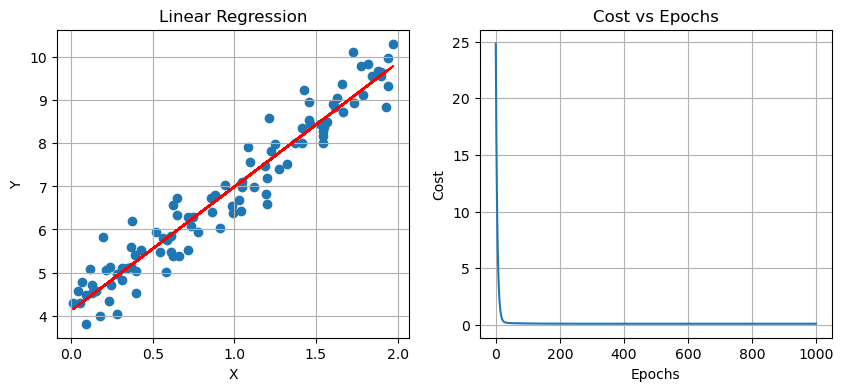

Prediction for x=1.5: 8.4306


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

model.plot_training(X, y)
x_new = np.array([1.5])
prediction = model.predict(x_new)
print(f"Prediction for x=1.5: {prediction[0]:.4f}")